# 02. Statistical Analysis

## 문화시설 활성화에 대한 운영·이용 현황 성과 분석

본 노트북은 EDA 이후 단계로, 박물관·미술관 관람객 수와 주요 운영·시설 요인 간의 관계를 **통계적으로 검정**하기 위한 노트북이다.

### 분석 목적

1. 박물관과 미술관의 관람객 수 차이가 통계적으로 유의한지 확인한다.
2. 지역별 관람객 수 차이가 통계적으로 유의한지 확인한다.
3. 시설 규모, 프로그램 수, 소장자료 수, 인력 변수와 관람객 수의 관계를 상관분석으로 확인한다.
4. 로그 관람객 수를 종속변수로 하는 회귀분석을 통해 주요 요인의 설명력을 확인한다.
5. 이후 머신러닝 모델링에서 사용할 변수 해석 근거를 정리한다.

### 주요 기준

- 목적변수는 `LOG1P_VIEWNG_NMPR_CO`를 기본으로 사용한다.
- `VIEWNG_NMPR_CO`는 실제 관람객 수 해석용으로만 사용한다.
- `DAY_AVRG_VIEWNG_NMPR_CO`, `LOG1P_DAY_AVRG_VIEWNG_NMPR_CO`는 관람객 수 기반 파생 변수이므로 입력·검정 변수에서 제외한다.
- 이상치 플래그는 제거 기준이 아니라 대형 시설 특성 해석 보조 지표로만 사용한다.

## 1. 라이브러리 및 데이터 불러오기

통계분석에는 `pandas`, `numpy`, `scipy`를 기본으로 사용한다.  
회귀분석은 `statsmodels`가 설치되어 있으면 실행하고, 설치되어 있지 않으면 안내 메시지를 출력하도록 구성한다.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# statsmodels는 회귀분석에 사용한다.
try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    STATSMODELS_AVAILABLE = True
except ModuleNotFoundError:
    STATSMODELS_AVAILABLE = False
    print("statsmodels가 설치되어 있지 않습니다. 회귀분석을 실행하려면 아래 명령어를 실행하세요.")
    print("python -m pip install statsmodels")

In [3]:
# 로컬 프로젝트 경로와 현재 작업 환경을 모두 고려한 데이터 경로 설정
candidate_paths = [
    Path("data/processed/facility_eda_preprocessed.csv"),
    Path("../data/processed/facility_eda_preprocessed.csv"),
    Path("/mnt/data/facility_eda_preprocessed.csv"),
]

DATA_PATH = None
for path in candidate_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError("facility_eda_preprocessed.csv 파일을 찾을 수 없습니다. data/processed 경로를 확인하세요.")

print(f"데이터 경로: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

print(f"데이터 크기: {df.shape[0]:,}행 × {df.shape[1]:,}열")
df.head()

데이터 경로: data\processed\facility_eda_preprocessed.csv
데이터 크기: 1,191행 × 64열


,facility_type,ID,FCLTY_NM,CTPRVN_NM,SIGNGU_NM,LEGALDONG_NM,ADSTRD_NM,FCLTY_LO,FCLTY_LA,OPNNG_DE,OPNNG_DE_RAW,OPNNG_DE_PRECISION,OPNNG_DAY_CO,BASE_DE,LAST_CHG_DE,LND_AR_VALUE,EDC_FCLTY_AR_VALUE,DATA_SPCE_AR_VALUE,NMPR_CO,QUALF_HOLD_CO,GNRL_GVRNM_EMP_CO,CNTRCT_EMP_CO,PUBLIC_VLNTER_CO,ARTGR_EMP_CO,PRFSN_CO,PRVATE_VLNTER_CO,DATA_CO,TOT_PROGRM_CO,VIEWNG_NMPR_CO,DAY_AVRG_VIEWNG_NMPR_CO,MOBILE_PROVD_AT,SOUND_PROVD_AT,HMPG_ADDR,TEL_NO,OPNNG_DAY_CO_IQR_OUTLIER,LND_AR_VALUE_IQR_OUTLIER,EDC_FCLTY_AR_VALUE_IQR_OUTLIER,DATA_SPCE_AR_VALUE_IQR_OUTLIER,NMPR_CO_IQR_OUTLIER,QUALF_HOLD_CO_IQR_OUTLIER,GNRL_GVRNM_EMP_CO_IQR_OUTLIER,CNTRCT_EMP_CO_IQR_OUTLIER,PUBLIC_VLNTER_CO_IQR_OUTLIER,ARTGR_EMP_CO_IQR_OUTLIER,PRFSN_CO_IQR_OUTLIER,PRVATE_VLNTER_CO_IQR_OUTLIER,DATA_CO_IQR_OUTLIER,TOT_PROGRM_CO_IQR_OUTLIER,VIEWNG_NMPR_CO_IQR_OUTLIER,DAY_AVRG_VIEWNG_NMPR_CO_IQR_OUTLIER,IQR_OUTLIER_FLAG_COUNT,OPNNG_YEAR,BASE_YEAR,OPERATING_YEARS,REGION_GROUP,SIDO_SIGUNGU,LOG1P_LND_AR_VALUE,LOG1P_EDC_FCLTY_AR_VALUE,LOG1P_DATA_SPCE_AR_VALUE,LOG1P_NMPR_CO,LOG1P_DATA_CO,LOG1P_TOT_PROGRM_CO,LOG1P_VIEWNG_NMPR_CO,LOG1P_DAY_AVRG_VIEWNG_NMPR_CO
0,박물관,KCDMMUS23N000000001,국립중앙박물관,서울,용산구,용산동6가,한강로동,126.9777,37.5247,1945-12-03,1945.12.03,day,360.0000,2025-03-27,2025-03-27,"285,991.0000","4,975.0000","1,552.0000",89.0000,5.0000,128.0000,NaN,213.0000,NaN,NaN,NaN,"157,323.0000",16.0000,"4,180,285.0000","11,612.0000",O,O,www.museum.go.kr,02-2077-9000,False,True,True,True,True,True,True,NaN,True,NaN,NaN,NaN,True,False,True,True,10,1945,2025,80,수도권,서울 용산구,12.5637,8.5124,7.3479,4.4998,11.9661,2.8332,15.2459,9.3599
1,박물관,KCDMMUS23N000000002,국립민속박물관,서울,종로구,세종로,청운효자동,126.9789,37.5817,1946-04-25,1946.04.25,day,362.0000,2025-03-27,2025-03-27,"39,626.6200","1,376.6800",324.0000,58.0000,1.0000,37.0000,8.0000,81.0000,NaN,NaN,NaN,"92,786.0000",70.0000,"1,307,690.0000","3,612.0000",O,X,www.nfm.go.kr,02-3704-3114,False,False,True,True,True,False,True,False,False,NaN,NaN,NaN,True,True,True,True,8,1946,2025,79,수도권,서울 종로구,10.5873,7.2282,5.7838,4.0775,11.4381,4.2627,14.0838,8.1923
2,박물관,KCDMMUS23N000000003,국립민속박물관 파주\n(개방형 수장고 및 정보센터),경기,파주시,탄현면 법흥리,탄현면,126.6939,37.7867,2021-07-23,2021.07.23,day,313.0000,2025-03-27,2025-03-27,"60,212.7000",277.4900,NaN,NaN,NaN,NaN,NaN,37.0000,NaN,NaN,NaN,NaN,10.0000,"83,306.0000",266.0000,X,X,www.nfm.go.kr,031-580-5800,False,True,False,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,False,False,False,1,2021,2025,4,수도권,경기 파주시,11.0057,5.6294,NaN,NaN,NaN,2.3979,11.3303,5.5872
3,박물관,KCDMMUS23N000000004,대한민국역사박물관,서울,종로구,세종로,종로1.2.3.4가동,126.9783,37.5737,2012-12-26,2012.12.26,day,362.0000,2025-03-27,2025-03-27,"6,445.0000",496.0000,81.0000,55.0000,23.0000,NaN,4.0000,54.0000,NaN,NaN,NaN,"18,065.0000",34.0000,"788,347.0000","2,178.0000",O,O,www.much.go.kr,02-3703-9200,False,False,False,False,True,True,NaN,False,False,NaN,NaN,NaN,False,True,True,True,5,2012,2025,13,수도권,서울 종로구,8.7712,6.2086,4.4067,4.0254,9.8018,3.5553,13.5777,7.6866
4,박물관,KCDMMUS23N000000005,국립한글박물관,서울,용산구,용산동6가,서빙고동,126.9805,37.5211,2014-10-09,2014.10.09,day,362.0000,2025-03-27,2025-03-27,"285,991.0000",378.0000,220.0000,33.0000,NaN,19.0000,13.0000,64.0000,NaN,NaN,NaN,"30,059.0000",33.0000,"397,107.0000","1,097.0000",O,O,www.hangeul.go.kr,02-2124-6200,False,True,False,True,True,NaN,True,True,False,NaN,NaN,NaN,True,True,True,True,9,2014,2025,11,수도권,서울 용산구,12.5637,5.9375,5.3982,3.5264,10.3110,3.5264,12.8920,7.0012


## 2. 분석 대상 변수 설정

EDA와 모델링 준비 노트북에서 정리한 기준을 그대로 사용한다.

- 기본 목적변수: `LOG1P_VIEWNG_NMPR_CO`
- 실제 관람객 수 해석 변수: `VIEWNG_NMPR_CO`
- 주요 그룹 변수: `facility_type`, `CTPRVN_NM`, `REGION_GROUP`
- 주요 수치형 변수: 운영연수, 개관일수, 시설 규모, 프로그램 수, 소장자료 수, 인력 변수

In [4]:
target = "LOG1P_VIEWNG_NMPR_CO"
raw_target = "VIEWNG_NMPR_CO"

# 기본 그룹 변수
group_vars = [
    "facility_type",
    "CTPRVN_NM",
    "REGION_GROUP",
]

# 상관분석에 사용할 주요 수치형 변수
numeric_candidates = [
    "OPERATING_YEARS",
    "OPNNG_DAY_CO",
    "LOG1P_LND_AR_VALUE",
    "LOG1P_EDC_FCLTY_AR_VALUE",
    "LOG1P_DATA_SPCE_AR_VALUE",
    "LOG1P_NMPR_CO",
    "LOG1P_DATA_CO",
    "LOG1P_TOT_PROGRM_CO",
    "ARTGR_EMP_CO",
    "QUALF_HOLD_CO",
    "GNRL_GVRNM_EMP_CO",
    "CNTRCT_EMP_CO",
    "PUBLIC_VLNTER_CO",
    "PRFSN_CO",
    "PRVATE_VLNTER_CO",
]

# 실제 존재하는 변수만 남기기
numeric_vars = [col for col in numeric_candidates if col in df.columns]
existing_group_vars = [col for col in group_vars if col in df.columns]

print("그룹 변수:", existing_group_vars)
print("수치형 후보 변수 수:", len(numeric_vars))
print(numeric_vars)

그룹 변수: ['facility_type', 'CTPRVN_NM', 'REGION_GROUP']
수치형 후보 변수 수: 15
['OPERATING_YEARS', 'OPNNG_DAY_CO', 'LOG1P_LND_AR_VALUE', 'LOG1P_EDC_FCLTY_AR_VALUE', 'LOG1P_DATA_SPCE_AR_VALUE', 'LOG1P_NMPR_CO', 'LOG1P_DATA_CO', 'LOG1P_TOT_PROGRM_CO', 'ARTGR_EMP_CO', 'QUALF_HOLD_CO', 'GNRL_GVRNM_EMP_CO', 'CNTRCT_EMP_CO', 'PUBLIC_VLNTER_CO', 'PRFSN_CO', 'PRVATE_VLNTER_CO']


In [5]:
# 목적변수 결측 제거
analysis_df = df.dropna(subset=[target]).copy()

print(f"원본 데이터: {df.shape[0]:,}행")
print(f"목적변수 결측 제거 후: {analysis_df.shape[0]:,}행")
print(f"제거된 행 수: {df.shape[0] - analysis_df.shape[0]:,}행")

analysis_df[["facility_type", "CTPRVN_NM", "REGION_GROUP", raw_target, target]].head()

원본 데이터: 1,191행
목적변수 결측 제거 후: 1,137행
제거된 행 수: 54행


,facility_type,CTPRVN_NM,REGION_GROUP,VIEWNG_NMPR_CO,LOG1P_VIEWNG_NMPR_CO
0,박물관,서울,수도권,"4,180,285.0000",15.2459
1,박물관,서울,수도권,"1,307,690.0000",14.0838
2,박물관,경기,수도권,"83,306.0000",11.3303
3,박물관,서울,수도권,"788,347.0000",13.5777
4,박물관,서울,수도권,"397,107.0000",12.8920


## 3. 통계분석 보조 함수 정의

반복적으로 사용할 요약 함수, 효과크기 함수, p-value 포맷 함수를 정의한다.

In [6]:
def format_pvalue(p):
    """p-value를 보기 좋게 표현하는 함수"""
    if pd.isna(p):
        return np.nan
    if p < 0.001:
        return "< 0.001"
    return f"{p:.4f}"


def significance_label(p):
    """일반적인 유의성 표시"""
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def cohens_d(x, y):
    """두 독립집단 간 Cohen's d 계산"""
    x = pd.Series(x).dropna().astype(float)
    y = pd.Series(y).dropna().astype(float)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    pooled_std = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    if pooled_std == 0:
        return np.nan
    return (x.mean() - y.mean()) / pooled_std


def epsilon_squared_kruskal(H, n, k):
    """Kruskal-Wallis 검정의 효과크기 근사값"""
    if n <= k:
        return np.nan
    return (H - k + 1) / (n - k)


def eta_squared_anova(data, group_col, value_col):
    """일원분산분석의 eta squared 계산"""
    tmp = data[[group_col, value_col]].dropna()
    grand_mean = tmp[value_col].mean()
    ss_between = tmp.groupby(group_col)[value_col].apply(
        lambda x: len(x) * (x.mean() - grand_mean) ** 2
    ).sum()
    ss_total = ((tmp[value_col] - grand_mean) ** 2).sum()
    if ss_total == 0:
        return np.nan
    return ss_between / ss_total


def group_summary(data, group_col, value_col=target, raw_col=raw_target):
    """그룹별 로그 관람객 수와 실제 관람객 수 요약"""
    summary = (
        data.groupby(group_col)
        .agg(
            n=(value_col, "size"),
            mean_log_viewers=(value_col, "mean"),
            median_log_viewers=(value_col, "median"),
            std_log_viewers=(value_col, "std"),
            mean_viewers=(raw_col, "mean"),
            median_viewers=(raw_col, "median"),
        )
        .reset_index()
        .sort_values("median_viewers", ascending=False)
    )
    return summary

## 4. 목적변수 분포와 기본 요약

통계 검정에 들어가기 전에 로그 관람객 수와 실제 관람객 수의 분포를 다시 확인한다.

In [7]:
distribution_summary = analysis_df[[raw_target, target]].describe().T

distribution_summary["skew"] = analysis_df[[raw_target, target]].skew(numeric_only=True)
distribution_summary["kurtosis"] = analysis_df[[raw_target, target]].kurtosis(numeric_only=True)

distribution_summary

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
VIEWNG_NMPR_CO,"1,137.0000","80,313.9420","233,939.8021",68.0000,"5,167.0000","20,000.0000","64,484.0000","4,180,285.0000",9.6193,127.6787
LOG1P_VIEWNG_NMPR_CO,"1,137.0000",9.8041,1.8267,4.2341,8.5502,9.9035,11.0742,15.2459,-0.1267,-0.2425


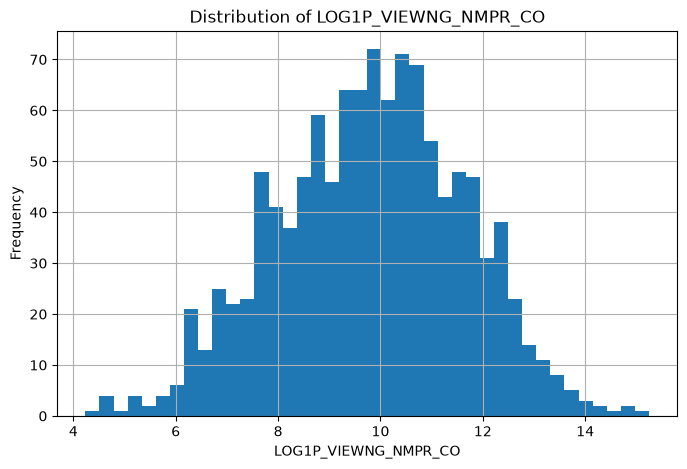

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
analysis_df[target].hist(bins=40, ax=ax)
ax.set_title("Distribution of LOG1P_VIEWNG_NMPR_CO")
ax.set_xlabel("LOG1P_VIEWNG_NMPR_CO")
ax.set_ylabel("Frequency")
plt.show()

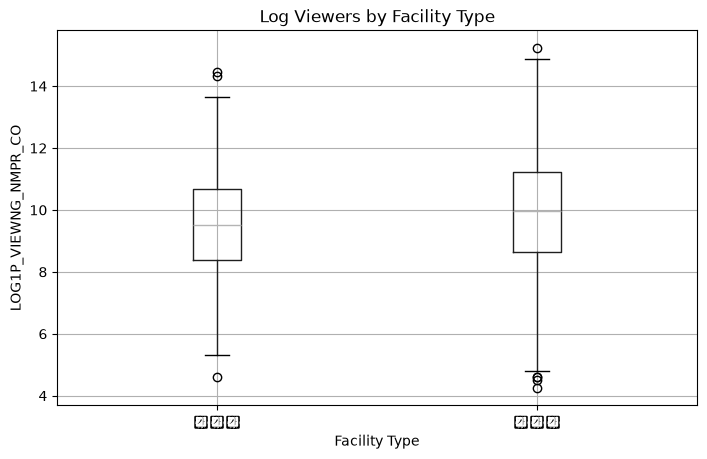

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
analysis_df.boxplot(column=target, by="facility_type", ax=ax)
ax.set_title("Log Viewers by Facility Type")
ax.set_xlabel("Facility Type")
ax.set_ylabel("LOG1P_VIEWNG_NMPR_CO")
plt.suptitle("")
plt.show()

## 5. 박물관과 미술관의 관람객 수 차이 검정

### 검정 질문

> 박물관과 미술관의 로그 관람객 수는 통계적으로 차이가 있는가?

### 사용 검정

- Welch's t-test: 두 집단의 평균 차이 검정, 등분산을 가정하지 않음
- Mann-Whitney U test: 정규성에 덜 민감한 비모수 검정
- Cohen's d: 평균 차이의 효과크기 확인

In [10]:
type_summary = group_summary(analysis_df, "facility_type")
type_summary

,facility_type,n,mean_log_viewers,median_log_viewers,std_log_viewers,mean_viewers,median_viewers
1,박물관,856,9.8804,9.9690,1.8616,"86,859.3762","21,353.0000"
0,미술관,281,9.5718,9.5031,1.6981,"60,374.8256","13,400.0000"


In [11]:
# 시설 유형이 정확히 2개인 경우에만 두 집단 검정 수행
type_values = analysis_df["facility_type"].dropna().unique()

if len(type_values) == 2:
    g1_name, g2_name = sorted(type_values)
    g1 = analysis_df.loc[analysis_df["facility_type"] == g1_name, target].dropna()
    g2 = analysis_df.loc[analysis_df["facility_type"] == g2_name, target].dropna()

    welch = stats.ttest_ind(g1, g2, equal_var=False)
    mann = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    d = cohens_d(g1, g2)

    type_test_result = pd.DataFrame({
        "comparison": [f"{g1_name} vs {g2_name}"],
        "n_1": [len(g1)],
        "n_2": [len(g2)],
        "mean_1": [g1.mean()],
        "mean_2": [g2.mean()],
        "median_1": [g1.median()],
        "median_2": [g2.median()],
        "welch_t": [welch.statistic],
        "welch_p": [welch.pvalue],
        "welch_sig": [significance_label(welch.pvalue)],
        "mannwhitney_u": [mann.statistic],
        "mannwhitney_p": [mann.pvalue],
        "mannwhitney_sig": [significance_label(mann.pvalue)],
        "cohens_d": [d],
    })

    display(type_test_result)
else:
    print("facility_type 그룹 수가 2개가 아니므로 두 집단 검정을 건너뜁니다.")

,comparison,n_1,n_2,mean_1,mean_2,median_1,median_2,welch_t,welch_p,welch_sig,mannwhitney_u,mannwhitney_p,mannwhitney_sig,cohens_d
0,미술관 vs 박물관,281,856,9.5718,9.8804,9.5031,9.9690,-2.5795,0.0102,*,"106,836.5000",0.0049,**,-0.1693


### 해석 가이드

- p-value가 0.05보다 작으면 박물관과 미술관의 로그 관람객 수 차이가 통계적으로 유의하다고 볼 수 있다.
- 다만 통계적으로 유의하더라도 효과크기(`cohens_d`)가 작으면 실제 차이의 크기는 제한적일 수 있다.
- 평균보다 중앙값과 분포를 함께 확인하는 것이 중요하다.

## 6. 지역별 관람객 수 차이 검정

### 검정 질문

> 지역별 로그 관람객 수는 통계적으로 차이가 있는가?

### 사용 검정

- One-way ANOVA: 로그 관람객 수의 평균 차이 검정
- Kruskal-Wallis test: 정규성에 덜 민감한 비모수 검정
- Eta squared / Epsilon squared: 지역 차이의 효과크기 확인

In [12]:
region_summary = group_summary(analysis_df, "CTPRVN_NM")
region_summary

,CTPRVN_NM,n,mean_log_viewers,median_log_viewers,std_log_viewers,mean_viewers,median_viewers
17,제주특별자치도,57,11.0926,11.3459,1.4623,"147,073.1053","84,617.0000"
16,제주,20,10.4483,10.5681,1.0645,"55,629.5500","39,635.5000"
15,전북특별자치도,38,10.1505,10.4717,1.9673,"87,471.1579","35,303.0000"
11,울산,11,10.7659,10.4528,0.9980,"72,789.6364","34,640.0000"
12,인천,36,9.7535,10.2819,1.8502,"57,082.5278","29,320.5000"
4,경북,79,9.8693,10.1309,1.7727,"66,986.2152","25,106.0000"
3,경남,82,10.0005,10.1024,1.4788,"56,053.9024","24,434.0000"
2,경기,184,9.6081,9.9093,1.7832,"53,165.5054","20,115.0000"
18,충남,70,9.9009,9.8483,1.9939,"140,097.6571","18,929.5000"
1,강원특별자치도,94,9.7285,9.7703,1.6863,"55,520.5745","17,531.5000"


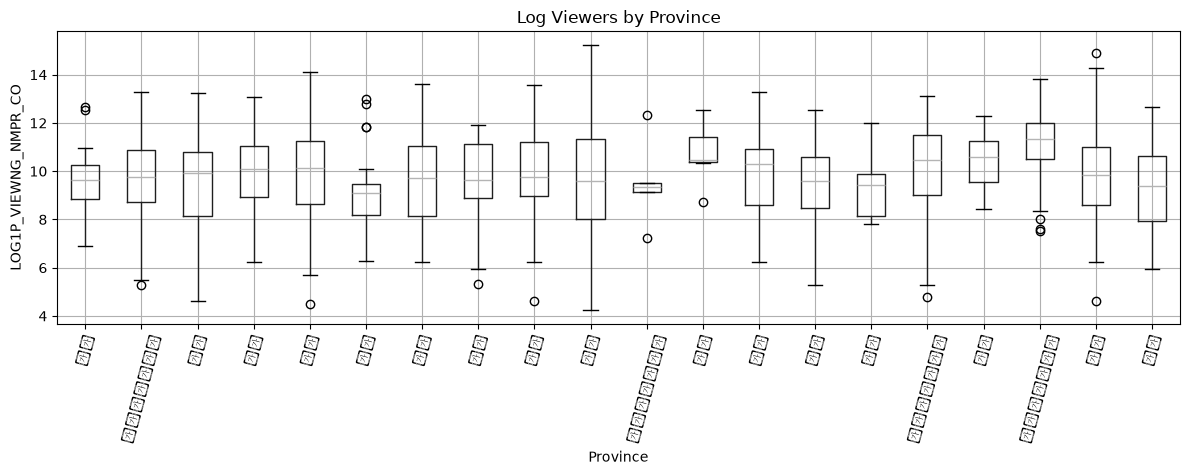

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
analysis_df.boxplot(column=target, by="CTPRVN_NM", ax=ax, rot=75)
ax.set_title("Log Viewers by Province")
ax.set_xlabel("Province")
ax.set_ylabel("LOG1P_VIEWNG_NMPR_CO")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [14]:
def group_difference_test(data, group_col, value_col=target, min_n=5):
    tmp = data[[group_col, value_col]].dropna().copy()
    counts = tmp[group_col].value_counts()
    valid_groups = counts[counts >= min_n].index.tolist()
    tmp = tmp[tmp[group_col].isin(valid_groups)]

    grouped_values = [group[value_col].values for _, group in tmp.groupby(group_col)]

    if len(grouped_values) < 2:
        return None

    # ANOVA
    anova = stats.f_oneway(*grouped_values)
    eta2 = eta_squared_anova(tmp, group_col, value_col)

    # Kruskal-Wallis
    kruskal = stats.kruskal(*grouped_values)
    eps2 = epsilon_squared_kruskal(kruskal.statistic, len(tmp), len(grouped_values))

    result = pd.DataFrame({
        "group_col": [group_col],
        "n_groups": [len(grouped_values)],
        "n_obs": [len(tmp)],
        "anova_F": [anova.statistic],
        "anova_p": [anova.pvalue],
        "anova_sig": [significance_label(anova.pvalue)],
        "eta_squared": [eta2],
        "kruskal_H": [kruskal.statistic],
        "kruskal_p": [kruskal.pvalue],
        "kruskal_sig": [significance_label(kruskal.pvalue)],
        "epsilon_squared": [eps2],
    })
    return result

province_test_result = group_difference_test(analysis_df, "CTPRVN_NM")
province_test_result

,group_col,n_groups,n_obs,anova_F,anova_p,anova_sig,eta_squared,kruskal_H,kruskal_p,kruskal_sig,epsilon_squared
0,CTPRVN_NM,20,1137,2.6410,0.0002,***,0.0430,55.8980,0.0000,***,0.0330


In [15]:
# 권역 단위 검정
if "REGION_GROUP" in analysis_df.columns:
    region_group_summary = group_summary(analysis_df, "REGION_GROUP")
    display(region_group_summary)

    region_group_test_result = group_difference_test(analysis_df, "REGION_GROUP")
    display(region_group_test_result)
else:
    print("REGION_GROUP 컬럼이 없습니다.")

,REGION_GROUP,n,mean_log_viewers,median_log_viewers,std_log_viewers,mean_viewers,median_viewers
4,제주권,77,10.9253,11.0678,1.3928,"123,321.5325","64,071.0000"
1,경상권,231,9.9211,10.1336,1.6960,"64,426.1688","25,173.0000"
2,수도권,392,9.6902,9.8299,1.9694,"98,789.1327","18,580.0000"
0,강원권,111,9.7115,9.7160,1.6629,"54,634.8018","16,579.0000"
5,충청권,141,9.6498,9.6159,1.9277,"90,994.3262","15,000.0000"
3,전라권,185,9.6057,9.5469,1.6873,"50,371.6000","14,000.0000"


,group_col,n_groups,n_obs,anova_F,anova_p,anova_sig,eta_squared,kruskal_H,kruskal_p,kruskal_sig,epsilon_squared
0,REGION_GROUP,6,1137,7.1808,0.0000,***,0.0308,39.8074,0.0000,***,0.0308


### 지역별 사후 비교

지역 전체 차이가 유의하다면, 어느 지역 간 차이가 있는지 확인하기 위해 Mann-Whitney U test를 지역 쌍별로 수행하고 Holm 보정을 적용한다.

주의: 쌍별 비교는 조합이 많기 때문에 보정 p-value를 기준으로 해석해야 한다.

In [16]:
def pairwise_mannwhitney(data, group_col, value_col=target, min_n=5):
    tmp = data[[group_col, value_col]].dropna().copy()
    counts = tmp[group_col].value_counts()
    valid_groups = counts[counts >= min_n].index.tolist()
    tmp = tmp[tmp[group_col].isin(valid_groups)]

    results = []
    groups = sorted(tmp[group_col].unique())

    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            g1, g2 = groups[i], groups[j]
            x = tmp.loc[tmp[group_col] == g1, value_col]
            y = tmp.loc[tmp[group_col] == g2, value_col]
            test = stats.mannwhitneyu(x, y, alternative="two-sided")
            results.append({
                "group_1": g1,
                "group_2": g2,
                "n_1": len(x),
                "n_2": len(y),
                "median_1": x.median(),
                "median_2": y.median(),
                "median_diff_1_minus_2": x.median() - y.median(),
                "u_statistic": test.statistic,
                "p_value": test.pvalue,
            })

    result_df = pd.DataFrame(results)
    if not result_df.empty:
        reject, p_adj, _, _ = multipletests(result_df["p_value"], method="holm")
        result_df["p_adj_holm"] = p_adj
        result_df["reject_0.05"] = reject
        result_df["sig"] = result_df["p_adj_holm"].apply(significance_label)
        result_df = result_df.sort_values("p_adj_holm")

    return result_df

province_pairwise = pairwise_mannwhitney(analysis_df, "CTPRVN_NM")
province_pairwise.head(20)

,group_1,group_2,n_1,n_2,median_1,median_2,median_diff_1_minus_2,u_statistic,p_value,p_adj_holm,reject_0.05,sig
51,경기,제주특별자치도,184,57,9.9093,11.3459,-1.4366,"2,711.0000",0.0000,0.0000,True,***
172,전남,제주특별자치도,101,57,9.6068,11.3459,-1.7391,"1,369.0000",0.0000,0.0000,True,***
34,강원특별자치도,제주특별자치도,94,57,9.7703,11.3459,-1.5756,"1,413.0000",0.0000,0.0002,True,***
188,제주특별자치도,충북,57,48,11.3459,9.3831,1.9628,"2,117.5000",0.0000,0.0003,True,***
142,서울,제주특별자치도,172,57,9.6058,11.3459,-1.7401,"2,963.0000",0.0000,0.0014,True,**
67,경남,제주특별자치도,82,57,10.1024,11.3459,-1.2435,"1,335.5000",0.0000,0.0034,True,**
96,광주,제주특별자치도,26,57,9.1005,11.3459,-2.2454,310.0000,0.0000,0.0044,True,**
82,경북,제주특별자치도,79,57,10.1309,11.3459,-1.2150,"1,316.5000",0.0000,0.0069,True,**
177,전북,제주특별자치도,20,57,9.4164,11.3459,-1.9296,219.0000,0.0000,0.0085,True,**
187,제주특별자치도,충남,57,70,11.3459,9.8483,1.4976,"2,817.0000",0.0001,0.0124,True,*


In [17]:
if "REGION_GROUP" in analysis_df.columns:
    region_group_pairwise = pairwise_mannwhitney(analysis_df, "REGION_GROUP")
    display(region_group_pairwise.head(20))

,group_1,group_2,n_1,n_2,median_1,median_2,median_diff_1_minus_2,u_statistic,p_value,p_adj_holm,reject_0.05,sig
12,전라권,제주권,185,77,9.5469,11.0678,-1.5209,"3,916.5000",0.0000,0.0000,True,***
10,수도권,제주권,392,77,9.8299,11.0678,-1.2379,"9,172.0000",0.0000,0.0000,True,***
14,제주권,충청권,77,141,11.0678,9.6159,1.4519,"7,693.0000",0.0000,0.0000,True,***
3,강원권,제주권,111,77,9.7160,11.0678,-1.3518,"2,432.5000",0.0000,0.0000,True,***
7,경상권,제주권,231,77,10.1336,11.0678,-0.9342,"5,749.5000",0.0000,0.0000,True,***
6,경상권,전라권,231,185,10.1336,9.5469,0.5867,"23,956.5000",0.0337,0.3366,False,n.s.
5,경상권,수도권,231,392,10.1336,9.8299,0.3037,"49,193.5000",0.0711,0.6395,False,n.s.
8,경상권,충청권,231,141,10.1336,9.6159,0.5177,"17,888.0000",0.1114,0.8908,False,n.s.
4,강원권,충청권,111,141,9.7160,9.6159,0.1001,"7,967.5000",0.8054,1.0000,False,n.s.
0,강원권,경상권,111,231,9.7160,10.1336,-0.4176,"11,647.0000",0.1706,1.0000,False,n.s.


## 7. 주요 수치형 변수와 관람객 수의 상관분석

### 검정 질문

> 운영연수, 시설 규모, 프로그램 수, 소장자료 수, 인력 변수는 로그 관람객 수와 어떤 관계가 있는가?

### 사용 지표

- Pearson correlation: 선형 관계 확인
- Spearman correlation: 순위 기반 단조 관계 확인, 이상치에 상대적으로 강함

EDA에서 이상치와 오른쪽 꼬리가 확인되었으므로 해석은 Spearman 상관계수를 우선 참고한다.

In [18]:
correlation_results = []

for col in numeric_vars:
    tmp = analysis_df[[col, target]].dropna()
    if len(tmp) < 3:
        continue

    pearson_r, pearson_p = stats.pearsonr(tmp[col], tmp[target])
    spearman_rho, spearman_p = stats.spearmanr(tmp[col], tmp[target])

    correlation_results.append({
        "variable": col,
        "n": len(tmp),
        "missing_rate": analysis_df[col].isna().mean(),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "pearson_sig": significance_label(pearson_p),
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
        "spearman_sig": significance_label(spearman_p),
    })

corr_df = pd.DataFrame(correlation_results)
corr_df = corr_df.sort_values("spearman_rho", ascending=False)
corr_df

,variable,n,missing_rate,pearson_r,pearson_p,pearson_sig,spearman_rho,spearman_p,spearman_sig
10,GNRL_GVRNM_EMP_CO,288,0.7467,0.4823,0.0000,***,0.6151,0.0000,***
9,QUALF_HOLD_CO,423,0.6280,0.3271,0.0000,***,0.5113,0.0000,***
1,OPNNG_DAY_CO,1136,0.0009,0.4490,0.0000,***,0.4870,0.0000,***
2,LOG1P_LND_AR_VALUE,1127,0.0088,0.4476,0.0000,***,0.4746,0.0000,***
11,CNTRCT_EMP_CO,170,0.8505,0.3113,0.0000,***,0.3690,0.0000,***
3,LOG1P_EDC_FCLTY_AR_VALUE,834,0.2665,0.3682,0.0000,***,0.3606,0.0000,***
12,PUBLIC_VLNTER_CO,183,0.8391,0.1152,0.1205,n.s.,0.3247,0.0000,***
4,LOG1P_DATA_SPCE_AR_VALUE,657,0.4222,0.2882,0.0000,***,0.2647,0.0000,***
13,PRFSN_CO,205,0.8197,0.3901,0.0000,***,0.2461,0.0004,***
7,LOG1P_TOT_PROGRM_CO,895,0.2128,0.2726,0.0000,***,0.2440,0.0000,***


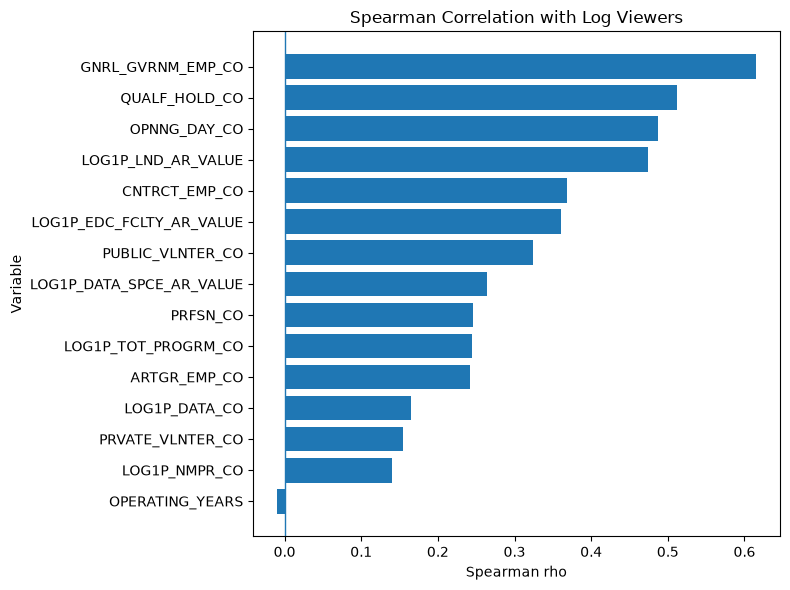

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_df = corr_df.sort_values("spearman_rho")
ax.barh(plot_df["variable"], plot_df["spearman_rho"])
ax.axvline(0, linewidth=1)
ax.set_title("Spearman Correlation with Log Viewers")
ax.set_xlabel("Spearman rho")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()

### 해석 가이드

- `spearman_rho`가 양수이면 해당 변수가 커질수록 관람객 수도 증가하는 경향이 있음을 의미한다.
- 일반적으로 0.1 내외는 약한 관계, 0.3 내외는 중간 정도의 관계, 0.5 이상은 비교적 강한 관계로 해석할 수 있다.
- 단, 결측률이 높은 변수는 상관계수가 높더라도 전체 시설에 일반화하기 어렵다.

## 8. 모바일/음성 제공 여부에 따른 관람객 수 차이

EDA에서 서비스 제공 여부 변수는 결측률이 낮은 편이므로, 보조적으로 관람객 수 차이를 확인한다.

In [20]:
service_vars = [col for col in ["MOBILE_PROVD_AT", "SOUND_PROVD_AT"] if col in analysis_df.columns]
service_results = []

for col in service_vars:
    tmp = analysis_df[[col, target, raw_target]].dropna().copy()
    counts = tmp[col].value_counts()
    valid_groups = counts[counts >= 5].index.tolist()
    tmp = tmp[tmp[col].isin(valid_groups)]

    display(group_summary(tmp, col))

    if tmp[col].nunique() == 2:
        groups = sorted(tmp[col].unique())
        x = tmp.loc[tmp[col] == groups[0], target]
        y = tmp.loc[tmp[col] == groups[1], target]
        welch = stats.ttest_ind(x, y, equal_var=False)
        mann = stats.mannwhitneyu(x, y, alternative="two-sided")
        service_results.append({
            "variable": col,
            "group_1": groups[0],
            "group_2": groups[1],
            "n_1": len(x),
            "n_2": len(y),
            "median_1": x.median(),
            "median_2": y.median(),
            "welch_p": welch.pvalue,
            "mannwhitney_p": mann.pvalue,
            "cohens_d": cohens_d(x, y),
        })
    elif tmp[col].nunique() > 2:
        test_result = group_difference_test(tmp, col)
        if test_result is not None:
            display(test_result)

service_test_df = pd.DataFrame(service_results)
if not service_test_df.empty:
    service_test_df["welch_sig"] = service_test_df["welch_p"].apply(significance_label)
    service_test_df["mannwhitney_sig"] = service_test_df["mannwhitney_p"].apply(significance_label)

service_test_df

,MOBILE_PROVD_AT,n,mean_log_viewers,median_log_viewers,std_log_viewers,mean_viewers,median_viewers
0,O,251,10.9070,11.0981,1.7195,"180,738.7251","66,042.0000"
1,X,880,9.4964,9.5799,1.7361,"52,138.4432","14,470.5000"


,SOUND_PROVD_AT,n,mean_log_viewers,median_log_viewers,std_log_viewers,mean_viewers,median_viewers
0,O,164,10.9253,10.9688,1.6205,"183,697.6098","58,032.0000"
1,X,967,9.6075,9.6159,1.7921,"62,657.7166","15,000.0000"


,variable,group_1,group_2,n_1,n_2,median_1,median_2,welch_p,mannwhitney_p,cohens_d,welch_sig,mannwhitney_sig
0,MOBILE_PROVD_AT,O,X,251,880,11.0981,9.5799,0.0000,0.0000,0.8142,***,***
1,SOUND_PROVD_AT,O,X,164,967,10.9688,9.6159,0.0000,0.0000,0.7452,***,***


## 9. 주요 변수의 결측 여부와 관람객 수 차이

결측률이 높은 변수는 단순히 대체하기 전에, 결측 여부 자체가 관람객 수와 관련이 있는지 확인한다.

예를 들어 인력 정보가 없는 시설과 있는 시설의 관람객 수 분포가 다르다면, 결측 여부 플래그가 모델링에서 의미를 가질 수 있다.

In [21]:
missing_check_vars = [
    "LOG1P_EDC_FCLTY_AR_VALUE",
    "LOG1P_DATA_SPCE_AR_VALUE",
    "LOG1P_NMPR_CO",
    "LOG1P_DATA_CO",
    "LOG1P_TOT_PROGRM_CO",
    "ARTGR_EMP_CO",
    "QUALF_HOLD_CO",
    "GNRL_GVRNM_EMP_CO",
    "CNTRCT_EMP_CO",
    "PUBLIC_VLNTER_CO",
    "PRFSN_CO",
    "PRVATE_VLNTER_CO",
]
missing_check_vars = [col for col in missing_check_vars if col in analysis_df.columns]

missing_results = []

for col in missing_check_vars:
    tmp = analysis_df[[col, target]].copy()
    tmp["is_missing"] = tmp[col].isna()

    observed = tmp.loc[~tmp["is_missing"], target].dropna()
    missing = tmp.loc[tmp["is_missing"], target].dropna()

    if len(observed) < 5 or len(missing) < 5:
        continue

    welch = stats.ttest_ind(observed, missing, equal_var=False)
    mann = stats.mannwhitneyu(observed, missing, alternative="two-sided")

    missing_results.append({
        "variable": col,
        "observed_n": len(observed),
        "missing_n": len(missing),
        "missing_rate": tmp["is_missing"].mean(),
        "observed_median_target": observed.median(),
        "missing_median_target": missing.median(),
        "median_diff_observed_minus_missing": observed.median() - missing.median(),
        "welch_p": welch.pvalue,
        "mannwhitney_p": mann.pvalue,
        "cohens_d": cohens_d(observed, missing),
    })

missing_test_df = pd.DataFrame(missing_results)
if not missing_test_df.empty:
    missing_test_df["welch_sig"] = missing_test_df["welch_p"].apply(significance_label)
    missing_test_df["mannwhitney_sig"] = missing_test_df["mannwhitney_p"].apply(significance_label)
    missing_test_df = missing_test_df.sort_values("mannwhitney_p")

missing_test_df

,variable,observed_n,missing_n,missing_rate,observed_median_target,missing_median_target,median_diff_observed_minus_missing,welch_p,mannwhitney_p,cohens_d,welch_sig,mannwhitney_sig
5,ARTGR_EMP_CO,520,617,0.5427,8.9446,10.5439,-1.5993,0.0000,0.0000,-0.7720,***,***
7,GNRL_GVRNM_EMP_CO,288,849,0.7467,11.0045,9.5000,1.5045,0.0000,0.0000,0.8289,***,***
9,PUBLIC_VLNTER_CO,183,954,0.8391,11.0774,9.5501,1.5273,0.0000,0.0000,0.8887,***,***
2,LOG1P_NMPR_CO,633,504,0.4433,10.2682,9.1200,1.1482,0.0000,0.0000,0.5484,***,***
8,CNTRCT_EMP_CO,170,967,0.8505,10.7875,9.6159,1.1716,0.0000,0.0000,0.6908,***,***
4,LOG1P_TOT_PROGRM_CO,895,242,0.2128,10.0136,9.1417,0.8720,0.0000,0.0000,0.4842,***,***
11,PRVATE_VLNTER_CO,114,1023,0.8997,8.8025,9.9839,-1.1814,0.0000,0.0000,-0.5041,***,***
0,LOG1P_EDC_FCLTY_AR_VALUE,834,303,0.2665,10.0488,9.2825,0.7663,0.0000,0.0000,0.2938,***,***
10,PRFSN_CO,205,932,0.8197,9.1592,10.0114,-0.8523,0.0001,0.0000,-0.3011,***,***
6,QUALF_HOLD_CO,423,714,0.6280,9.9758,9.8209,0.1549,0.0067,0.0161,0.1634,**,*


## 10. 기본 회귀분석

### 분석 질문

> 시설 유형, 권역, 운영연수, 개관일수, 시설 규모, 교육시설면적, 프로그램 수를 동시에 고려했을 때 로그 관람객 수와 유의한 관계를 보이는 변수는 무엇인가?

### 회귀식

```text
LOG1P_VIEWNG_NMPR_CO
~ facility_type
+ REGION_GROUP
+ OPERATING_YEARS
+ OPNNG_DAY_CO
+ LOG1P_LND_AR_VALUE
+ LOG1P_EDC_FCLTY_AR_VALUE
+ LOG1P_TOT_PROGRM_CO
```

주의: 회귀분석은 인과관계가 아니라 통계적 관계를 확인하는 분석이다.

In [22]:
regression_vars = [
    target,
    "facility_type",
    "REGION_GROUP",
    "OPERATING_YEARS",
    "OPNNG_DAY_CO",
    "LOG1P_LND_AR_VALUE",
    "LOG1P_EDC_FCLTY_AR_VALUE",
    "LOG1P_TOT_PROGRM_CO",
]
regression_vars = [col for col in regression_vars if col in analysis_df.columns]

reg_df = analysis_df[regression_vars].dropna().copy()

print(f"회귀분석 사용 행 수: {len(reg_df):,}")
print(f"전체 목적변수 유효 행 대비 비율: {len(reg_df) / len(analysis_df):.2%}")
reg_df.head()

회귀분석 사용 행 수: 716
전체 목적변수 유효 행 대비 비율: 62.97%


,LOG1P_VIEWNG_NMPR_CO,facility_type,REGION_GROUP,OPERATING_YEARS,OPNNG_DAY_CO,LOG1P_LND_AR_VALUE,LOG1P_EDC_FCLTY_AR_VALUE,LOG1P_TOT_PROGRM_CO
0,15.2459,박물관,수도권,80,360.0000,12.5637,8.5124,2.8332
1,14.0838,박물관,수도권,79,362.0000,10.5873,7.2282,4.2627
2,11.3303,박물관,수도권,4,313.0000,11.0057,5.6294,2.3979
3,13.5777,박물관,수도권,13,362.0000,8.7712,6.2086,3.5553
4,12.8920,박물관,수도권,11,362.0000,12.5637,5.9375,3.5264


In [23]:
if STATSMODELS_AVAILABLE:
    formula_basic = (
        "LOG1P_VIEWNG_NMPR_CO ~ "
        "C(facility_type) + C(REGION_GROUP) + "
        "OPERATING_YEARS + OPNNG_DAY_CO + "
        "LOG1P_LND_AR_VALUE + LOG1P_EDC_FCLTY_AR_VALUE + LOG1P_TOT_PROGRM_CO"
    )

    ols_basic = smf.ols(formula=formula_basic, data=reg_df).fit(cov_type="HC3")
    print(ols_basic.summary())
else:
    print("statsmodels가 없어 회귀분석을 건너뜁니다.")

                             OLS Regression Results                             
Dep. Variable:     LOG1P_VIEWNG_NMPR_CO   R-squared:                       0.442
Model:                              OLS   Adj. R-squared:                  0.434
Method:                   Least Squares   F-statistic:                     47.67
Date:                  Thu, 25 Jun 2026   Prob (F-statistic):           1.00e-77
Time:                          17:12:37   Log-Likelihood:                -1180.6
No. Observations:                   716   AIC:                             2385.
Df Residuals:                       704   BIC:                             2440.
Df Model:                            11                                         
Covariance Type:                    HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Inte

In [24]:
if STATSMODELS_AVAILABLE:
    coef_basic = ols_basic.summary2().tables[1].reset_index().rename(columns={"index": "term"})
    coef_basic["sig"] = coef_basic["P>|z|"].apply(significance_label) if "P>|z|" in coef_basic.columns else coef_basic.iloc[:, 4].apply(significance_label)
    coef_basic

### 회귀분석 해석 가이드

- 계수가 양수이면 다른 변수를 통제했을 때 해당 변수가 커질수록 로그 관람객 수가 증가하는 방향의 관계를 보인다.
- p-value가 0.05보다 작으면 통계적으로 유의한 관계가 있다고 볼 수 있다.
- 범주형 변수의 계수는 기준 범주 대비 차이로 해석한다.
- 로그 목적변수를 사용했으므로 계수는 관람객 수의 비율 변화에 가까운 방향으로 해석한다.

## 11. 시설 유형별 영향 차이 확인: 상호작용 회귀

박물관과 미술관은 운영 방식과 시설 특성이 다르므로, 주요 수치형 변수의 영향이 시설 유형에 따라 달라질 수 있다.

여기서는 시설 유형과 주요 수치형 변수 간의 상호작용항을 추가해 비교한다.

In [25]:
if STATSMODELS_AVAILABLE:
    formula_interaction = (
        "LOG1P_VIEWNG_NMPR_CO ~ "
        "C(facility_type) + C(REGION_GROUP) + "
        "OPERATING_YEARS + OPNNG_DAY_CO + "
        "LOG1P_LND_AR_VALUE + LOG1P_EDC_FCLTY_AR_VALUE + LOG1P_TOT_PROGRM_CO + "
        "C(facility_type):LOG1P_LND_AR_VALUE + "
        "C(facility_type):LOG1P_EDC_FCLTY_AR_VALUE + "
        "C(facility_type):LOG1P_TOT_PROGRM_CO"
    )

    ols_interaction = smf.ols(formula=formula_interaction, data=reg_df).fit(cov_type="HC3")
    print(ols_interaction.summary())
else:
    print("statsmodels가 없어 상호작용 회귀분석을 건너뜁니다.")

                             OLS Regression Results                             
Dep. Variable:     LOG1P_VIEWNG_NMPR_CO   R-squared:                       0.450
Model:                              OLS   Adj. R-squared:                  0.439
Method:                   Least Squares   F-statistic:                     40.74
Date:                  Thu, 25 Jun 2026   Prob (F-statistic):           5.47e-81
Time:                          17:12:37   Log-Likelihood:                -1175.5
No. Observations:                   716   AIC:                             2381.
Df Residuals:                       701   BIC:                             2450.
Df Model:                            14                                         
Covariance Type:                    HC3                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [26]:
if STATSMODELS_AVAILABLE:
    model_compare = pd.DataFrame({
        "model": ["basic", "interaction"],
        "nobs": [ols_basic.nobs, ols_interaction.nobs],
        "r_squared": [ols_basic.rsquared, ols_interaction.rsquared],
        "adj_r_squared": [ols_basic.rsquared_adj, ols_interaction.rsquared_adj],
        "aic": [ols_basic.aic, ols_interaction.aic],
        "bic": [ols_basic.bic, ols_interaction.bic],
    })
    display(model_compare)

    interaction_terms = ols_interaction.summary2().tables[1].reset_index().rename(columns={"index": "term"})
    interaction_terms[interaction_terms["term"].str.contains(":", regex=False)]

,model,nobs,r_squared,adj_r_squared,aic,bic
0,basic,716.0000,0.4423,0.4335,"2,385.2761","2,440.1602"
1,interaction,716.0000,0.4502,0.4392,"2,380.9889","2,449.5941"


## 12. 시설 유형별 별도 상관분석

상호작용 회귀와 함께, 박물관과 미술관을 분리하여 주요 변수와 관람객 수의 상관관계를 확인한다.

In [27]:
by_type_corr_results = []

for facility_type, sub_df in analysis_df.groupby("facility_type"):
    for col in numeric_vars:
        tmp = sub_df[[col, target]].dropna()
        if len(tmp) < 10:
            continue
        rho, p = stats.spearmanr(tmp[col], tmp[target])
        by_type_corr_results.append({
            "facility_type": facility_type,
            "variable": col,
            "n": len(tmp),
            "spearman_rho": rho,
            "p_value": p,
            "sig": significance_label(p),
        })

by_type_corr_df = pd.DataFrame(by_type_corr_results)
by_type_corr_df = by_type_corr_df.sort_values(["variable", "facility_type"])
by_type_corr_df

,facility_type,variable,n,spearman_rho,p_value,sig
8,미술관,ARTGR_EMP_CO,198,0.3695,0.0000,***
23,박물관,ARTGR_EMP_CO,322,0.1724,0.0019,**
11,미술관,CNTRCT_EMP_CO,46,0.4847,0.0006,***
26,박물관,CNTRCT_EMP_CO,124,0.3318,0.0002,***
10,미술관,GNRL_GVRNM_EMP_CO,40,0.6280,0.0000,***
25,박물관,GNRL_GVRNM_EMP_CO,248,0.6120,0.0000,***
6,미술관,LOG1P_DATA_CO,156,0.3308,0.0000,***
21,박물관,LOG1P_DATA_CO,485,0.1028,0.0235,*
4,미술관,LOG1P_DATA_SPCE_AR_VALUE,171,0.2828,0.0002,***
19,박물관,LOG1P_DATA_SPCE_AR_VALUE,486,0.2467,0.0000,***


In [28]:
# 변수별로 박물관/미술관 상관계수 차이를 보기 쉽게 피벗
if not by_type_corr_df.empty:
    by_type_corr_pivot = by_type_corr_df.pivot_table(
        index="variable",
        columns="facility_type",
        values="spearman_rho"
    )
    by_type_corr_pivot

## 13. 주요 결과 테이블 저장

통계분석 결과를 CSV로 저장하면 이후 보고서, 발표자료, 태블로 대시보드 기획에 재사용하기 쉽다.

In [29]:
SAVE_OUTPUT = True

if SAVE_OUTPUT:
    output_dir_candidates = [
        Path("outputs/statistics"),
        Path("../outputs/statistics"),
        Path("/mnt/data/statistics_outputs"),
    ]

    OUTPUT_DIR = None
    for path in output_dir_candidates[:2]:
        try:
            path.mkdir(parents=True, exist_ok=True)
            OUTPUT_DIR = path
            break
        except Exception:
            continue

    if OUTPUT_DIR is None:
        OUTPUT_DIR = output_dir_candidates[-1]
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    type_summary.to_csv(OUTPUT_DIR / "type_summary.csv", index=False, encoding="utf-8-sig")
    region_summary.to_csv(OUTPUT_DIR / "province_summary.csv", index=False, encoding="utf-8-sig")
    corr_df.to_csv(OUTPUT_DIR / "correlation_results.csv", index=False, encoding="utf-8-sig")
    missing_test_df.to_csv(OUTPUT_DIR / "missingness_test_results.csv", index=False, encoding="utf-8-sig")
    province_pairwise.to_csv(OUTPUT_DIR / "province_pairwise_mannwhitney_holm.csv", index=False, encoding="utf-8-sig")

    if "type_test_result" in globals():
        type_test_result.to_csv(OUTPUT_DIR / "facility_type_test_result.csv", index=False, encoding="utf-8-sig")

    if "province_test_result" in globals() and province_test_result is not None:
        province_test_result.to_csv(OUTPUT_DIR / "province_difference_test_result.csv", index=False, encoding="utf-8-sig")

    if "region_group_test_result" in globals() and region_group_test_result is not None:
        region_group_test_result.to_csv(OUTPUT_DIR / "region_group_difference_test_result.csv", index=False, encoding="utf-8-sig")

    if "service_test_df" in globals() and not service_test_df.empty:
        service_test_df.to_csv(OUTPUT_DIR / "service_test_results.csv", index=False, encoding="utf-8-sig")

    if "by_type_corr_df" in globals() and not by_type_corr_df.empty:
        by_type_corr_df.to_csv(OUTPUT_DIR / "by_type_correlation_results.csv", index=False, encoding="utf-8-sig")

    if STATSMODELS_AVAILABLE and "coef_basic" in globals():
        coef_basic.to_csv(OUTPUT_DIR / "ols_basic_coefficients.csv", index=False, encoding="utf-8-sig")

    print(f"결과 저장 완료: {OUTPUT_DIR}")
else:
    print("SAVE_OUTPUT = False 이므로 결과를 저장하지 않습니다.")

결과 저장 완료: outputs\statistics


## 14. 통계분석 결과 정리 템플릿

아래 문장은 실행 결과를 확인한 뒤 수치와 방향을 채워 최종 보고서 문장으로 다듬으면 된다.

In [30]:
summary_template = """
[통계분석 결과 요약 초안]

1. 박물관과 미술관의 로그 관람객 수 차이를 검정한 결과, Welch's t-test와 Mann-Whitney U test를 통해 두 시설 유형 간 차이 여부를 확인하였다.
   p-value와 효과크기를 함께 고려하여 단순한 통계적 유의성뿐 아니라 실제 차이의 크기도 해석하였다.

2. 시도 및 권역별 관람객 수 차이를 검정한 결과, 지역 간 로그 관람객 수 분포에 차이가 있는지 확인하였다.
   전체 차이가 유의한 경우 쌍별 비교 결과는 Holm 보정 p-value를 기준으로 해석하였다.

3. 주요 수치형 변수와 로그 관람객 수의 상관분석 결과, 시설 규모 및 교육시설면적, 프로그램 수 등 일부 변수에서 양의 상관관계가 확인되었다.
   다만 소장자료 수와 인력 변수는 결측률이 높으므로 결과 해석에 주의가 필요하다.

4. 기본 회귀분석에서는 시설 유형, 권역, 운영연수, 개관일수, 시설 규모, 교육시설면적, 프로그램 수를 동시에 고려하였다.
   회귀계수의 방향성과 유의성을 통해 관람객 수와 관련된 주요 요인을 확인하였다.

5. 상호작용 회귀와 시설 유형별 상관분석을 통해 박물관과 미술관에서 주요 변수의 영향 방향이 다를 가능성을 검토하였다.
   해당 결과는 이후 머신러닝 모델링 및 대시보드 해석 지표 선정의 근거로 활용할 수 있다.
"""

print(summary_template)


[통계분석 결과 요약 초안]

1. 박물관과 미술관의 로그 관람객 수 차이를 검정한 결과, Welch's t-test와 Mann-Whitney U test를 통해 두 시설 유형 간 차이 여부를 확인하였다.
   p-value와 효과크기를 함께 고려하여 단순한 통계적 유의성뿐 아니라 실제 차이의 크기도 해석하였다.

2. 시도 및 권역별 관람객 수 차이를 검정한 결과, 지역 간 로그 관람객 수 분포에 차이가 있는지 확인하였다.
   전체 차이가 유의한 경우 쌍별 비교 결과는 Holm 보정 p-value를 기준으로 해석하였다.

3. 주요 수치형 변수와 로그 관람객 수의 상관분석 결과, 시설 규모 및 교육시설면적, 프로그램 수 등 일부 변수에서 양의 상관관계가 확인되었다.
   다만 소장자료 수와 인력 변수는 결측률이 높으므로 결과 해석에 주의가 필요하다.

4. 기본 회귀분석에서는 시설 유형, 권역, 운영연수, 개관일수, 시설 규모, 교육시설면적, 프로그램 수를 동시에 고려하였다.
   회귀계수의 방향성과 유의성을 통해 관람객 수와 관련된 주요 요인을 확인하였다.

5. 상호작용 회귀와 시설 유형별 상관분석을 통해 박물관과 미술관에서 주요 변수의 영향 방향이 다를 가능성을 검토하였다.
   해당 결과는 이후 머신러닝 모델링 및 대시보드 해석 지표 선정의 근거로 활용할 수 있다.



## 최종 정리

본 노트북에서는 EDA 결과를 바탕으로 관람객 수와 주요 운영·시설 요인 간의 관계를 통계적으로 검정하였다. 관람객 수는 오른쪽 꼬리가 긴 분포를 보였기 때문에, 분석에서는 `LOG1P_VIEWNG_NMPR_CO`를 주요 종속변수로 사용하였다.

시설 유형별 분석 결과, 박물관과 미술관의 로그 관람객 수 분포에는 통계적으로 유의한 차이가 확인되었다. 박물관의 중앙값은 미술관보다 높게 나타났지만, 효과크기 Cohen's d는 약 -0.17 수준으로 크지 않아 시설 유형 차이는 통계적으로는 유의하되 실제 차이의 크기는 제한적으로 해석할 필요가 있다.

지역별 분석에서는 시도 단위와 권역 단위 모두에서 로그 관람객 수 차이가 유의하게 나타났다. 특히 제주권은 다른 권역에 비해 관람객 수 중앙값이 높게 나타났으며, 이는 EDA에서 확인한 제주 지역의 높은 관람객 수 특성과 일관된다.

상관분석 결과, 개관일수, 로그 변환 토지면적, 로그 변환 교육시설면적 등이 로그 관람객 수와 비교적 뚜렷한 양의 관계를 보였다. 반면 소장자료 수와 프로그램 수는 양의 관계가 확인되었지만 강도는 상대적으로 약했다. 인력 변수 일부도 관람객 수와 양의 관계를 보였으나, 결측률이 높기 때문에 해석에 주의가 필요하다.

모바일 제공 여부와 음성 제공 여부에 따른 관람객 수 차이도 유의하게 나타났다. 제공 시설의 로그 관람객 수 중앙값이 미제공 시설보다 높게 나타났으나, 이는 서비스 제공 자체의 효과라기보다 대형 시설일수록 관련 서비스를 갖추고 있을 가능성도 함께 고려해야 한다.

기본 회귀분석 결과, 모델의 설명력은 R² 약 0.442 수준으로 나타났다. 개관일수, 시설 규모, 교육시설면적, 프로그램 수 등 일부 변수는 다른 요인을 동시에 고려한 뒤에도 관람객 수와 관련된 요인으로 확인되었다. 상호작용 회귀모형은 기본 모형보다 R²가 약간 높았지만 개선 폭은 크지 않아, 시설 유형별 영향 차이는 추가적인 머신러닝 모델과 변수 중요도 분석을 통해 보완적으로 확인할 필요가 있다.

따라서 통계분석 결과를 종합하면, 문화시설 관람객 수는 단일 요인보다는 지역, 시설 규모, 개관일수, 교육시설면적, 프로그램 운영 여부, 서비스 제공 여부 등이 복합적으로 관련되어 있다고 볼 수 있다. 다음 단계에서는 머신러닝 모델링을 통해 이러한 변수들이 예측 성능에 얼마나 기여하는지 비교하고, 변수 중요도를 통해 문화시설 활성화와 관련된 핵심 요인을 추가로 해석한다.